## Fine Tuning with 101 classes Food Data


In [1]:
# Download helper functions

!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/refs/heads/main/extras/helper_functions.py

--2026-07-07 20:02:28--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/refs/heads/main/extras/helper_functions.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10246 (10K) [text/plain]
Saving to: ‘helper_functions.py’

helper_functions.py 100%[===================>]  10.01K  --.-KB/s    in 0s      

2026-07-07 20:02:28 (122 MB/s) - ‘helper_functions.py’ saved [10246/10246]



In [2]:
from helper_functions import walk_through_dir, unzip_data, plot_loss_curves, compare_historys, make_confusion_matrix

## Using only 10% of the data


In [3]:
# Downloading the data

!wget https://storage.googleapis.com/ztm_tf_course/food_vision/101_food_classes_10_percent.zip

--2026-07-07 20:02:41--  https://storage.googleapis.com/ztm_tf_course/food_vision/101_food_classes_10_percent.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.250.99.207, 172.253.117.207, 142.251.188.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.250.99.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1625420029 (1.5G) [application/zip]
Saving to: ‘101_food_classes_10_percent.zip’

101_food_classes_10 100%[===================>]   1.51G   231MB/s    in 7.4s    

2026-07-07 20:02:49 (209 MB/s) - ‘101_food_classes_10_percent.zip’ saved [1625420029/1625420029]



In [4]:
unzip_data("101_food_classes_10_percent.zip")

In [5]:
train_dir = "101_food_classes_10_percent/train/"
test_dir = "101_food_classes_10_percent/test/"

In [6]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_data_10_percent = tf.keras.preprocessing.image_dataset_from_directory(
    directory=train_dir,
    image_size=IMG_SIZE,
    label_mode="categorical",
    seed=42,
    batch_size=BATCH_SIZE,
)

test_data_10_percent = tf.keras.preprocessing.image_dataset_from_directory(
    directory=test_dir,
    image_size=IMG_SIZE,
    label_mode="categorical",
    seed=42,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

Found 7575 files belonging to 101 classes.
Found 25250 files belonging to 101 classes.


In [7]:
checkpoint_path = "101_classes_10_percent_data_model_checkpoint.weights.h5"
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    checkpoint_path,
    monitor="val_accuracy",
    save_best_only=True,
    save_weights_only=True,
)

In [8]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomHeight(0.2),
    tf.keras.layers.RandomWidth(0.2),
], name="data_augmentation")

base_model = tf.keras.applications.EfficientNetB0(include_top=False)
base_model.trainable = False

inputs = tf.keras.layers.Input(shape=(224, 224, 3), name="input_layer")

x = data_augmentation(inputs)
x = base_model(x, training=False)

x = tf.keras.layers.GlobalAveragePooling2D()(x)
outputs = tf.keras.layers.Dense(101, activation="softmax", name="output_layer")(x)

model_1 = tf.keras.Model(inputs, outputs)

model_1.compile(
    loss="categorical_crossentropy",  # use "sparse_categorical_crossentropy" if your labels are integers, not one-hot
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"],
)

history_1 = model_1.fit(
    train_data_10_percent,
    epochs=5,
    validation_data=test_data_10_percent,
    callbacks=[checkpoint_callback]
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 105s 385ms/step - accuracy: 0.2601 - loss: 3.4214 - val_accuracy: 0.4659 - val_loss: 2.3450
Epoch 2/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 136s 378ms/step - accuracy: 0.4738 - loss: 2.2753 - val_accuracy: 0.5372 - val_loss: 1.8991
Epoch 3/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 91s 384ms/step - accuracy: 0.5509 - loss: 1.8818 - val_accuracy: 0.5586 - val_loss: 1.7264
Epoch 4/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 90s 382ms/step - accuracy: 0.5914 - loss: 1.6834 - val_accuracy: 0.5644 - val_loss: 1.6562
Epoch 5/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 111s 469ms/step - accuracy: 0.6271 - loss: 1.5166 - val_accuracy: 0.5789 - val_loss: 1.5959


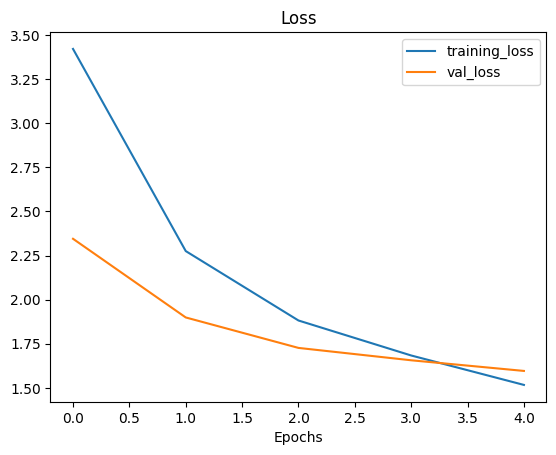

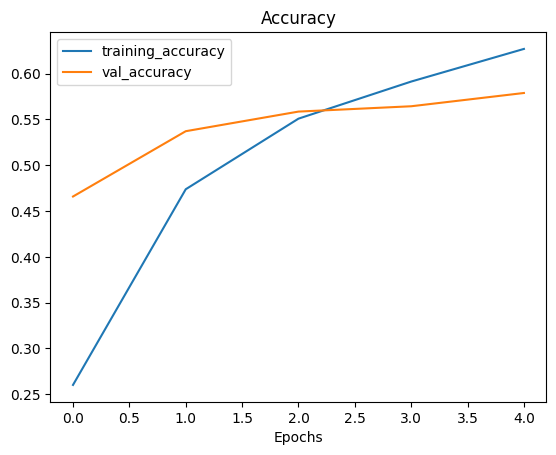

In [9]:
plot_loss_curves(history_1)

## Fine tuning on the feature extracted data


In [10]:
model_2 = model_1

base_model = model_2.layers[2]
base_model.trainable = True

# refreeze every layer except the last 5
for layer in base_model.layers[:-10]:
  layer.trainable = False

model_2.compile(
    loss="categorical_crossentropy",  # use "sparse_categorical_crossentropy" if your labels are integers, not one-hot
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), # during fine tuning lower the learning rate by 10x
    metrics=["accuracy"],
)

epochs = 5
fine_tune_epochs = epochs + 5

history_2 = model_2.fit(
    train_data_10_percent,
    epochs=fine_tune_epochs,
    validation_data=test_data_10_percent,
    initial_epoch=history_1.epoch[-1],
)

Epoch 5/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 125s 480ms/step - accuracy: 0.6463 - loss: 1.4508 - val_accuracy: 0.5929 - val_loss: 1.5219
Epoch 6/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 139s 470ms/step - accuracy: 0.6763 - loss: 1.3082 - val_accuracy: 0.5998 - val_loss: 1.4871
Epoch 7/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 121s 381ms/step - accuracy: 0.7022 - loss: 1.2085 - val_accuracy: 0.6067 - val_loss: 1.4576
Epoch 8/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 111s 468ms/step - accuracy: 0.7176 - loss: 1.1404 - val_accuracy: 0.6109 - val_loss: 1.4380
Epoch 9/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 122s 382ms/step - accuracy: 0.7300 - loss: 1.0880 - val_accuracy: 0.6148 - val_loss: 1.4248
Epoch 10/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 90s 382ms/step - accuracy: 0.7427 - loss: 1.0229 - val_accuracy: 0.6190 - val_loss: 1.4082


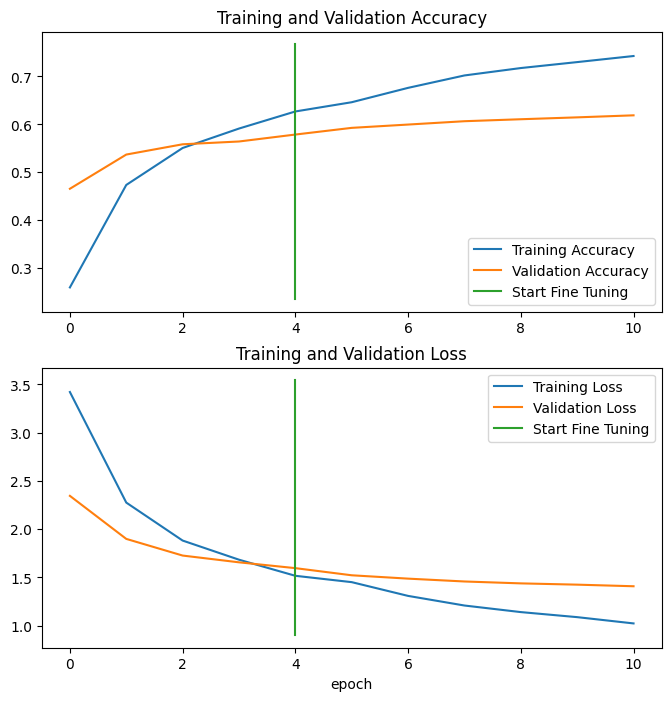

In [11]:
compare_historys(history_1, history_2, initial_epochs=5)

## See Random Result


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


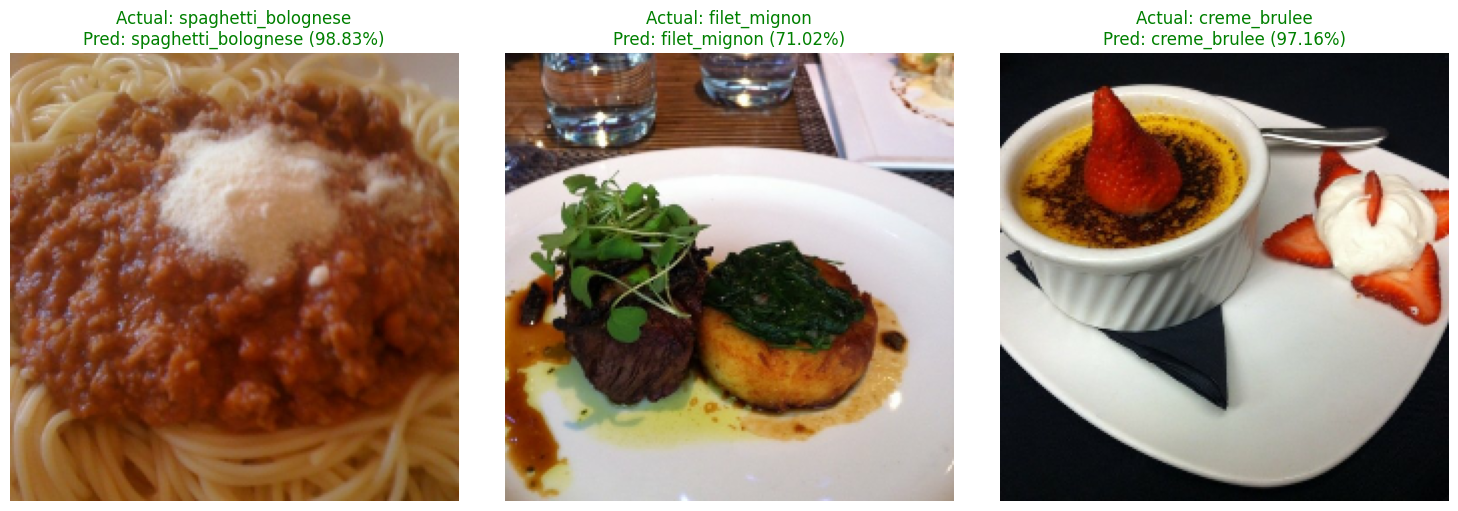

In [14]:
import random
import matplotlib.pyplot as plt
import os
import tensorflow as tf

class_names = train_data_10_percent.class_names

def pred_and_plot_random_image(model, test_dir, class_names, ax):
    # 1. Choose a random class and a random image from that class folder
    target_class = random.choice(class_names)
    target_dir = os.path.join(test_dir, target_class)
    random_image = random.choice(os.listdir(target_dir))
    image_path = os.path.join(target_dir, random_image)

    # 2. Read and preprocess the image
    img = tf.io.read_file(image_path)
    img = tf.image.decode_image(img, channels=3)
    img = tf.image.resize(img, size=[224, 224])

    # 3. Make prediction
    pred_probs = model.predict(tf.expand_dims(img, axis=0))
    pred_class = class_names[pred_probs.argmax()]
    conf_score = pred_probs.max()

    img = img / 255.0

    # 4. Plot the image onto the given axis (instead of plt.imshow + plt.show)
    ax.imshow(img)
    title_color = "green" if pred_class == target_class else "red"
    ax.set_title(f"Actual: {target_class}\nPred: {pred_class} ({conf_score:.2%})", color=title_color)
    ax.axis(False)

# Create one figure with 3 subplots side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax in axes:
    pred_and_plot_random_image(model_2, test_dir, class_names, ax)

plt.tight_layout()
plt.show()

## Confusion Matrix


In [16]:
import itertools
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Our function needs a different name to sklearn's plot_confusion_matrix
def make_confusion_matrix(y_true, y_pred, classes=None, figsize=(10, 10), text_size=15, norm=False, savefig=False):
  # Create the confustion matrix
  cm = confusion_matrix(y_true, y_pred)
  cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis] # normalize it
  n_classes = cm.shape[0] # find the number of classes we're dealing with

  # Plot the figure and make it pretty
  fig, ax = plt.subplots(figsize=figsize)
  cax = ax.matshow(cm, cmap=plt.cm.Blues) # colors will represent how 'correct' a class is, darker == better
  fig.colorbar(cax)

  # Are there a list of classes?
  if classes:
    labels = classes
  else:
    labels = np.arange(cm.shape[0])

  # Label the axes
  ax.set(title="Confusion Matrix",
         xlabel="Predicted label",
         ylabel="True label",
         xticks=np.arange(n_classes), # create enough axis slots for each class
         yticks=np.arange(n_classes),
         xticklabels=labels, # axes will labeled with class names (if they exist) or ints
         yticklabels=labels)

  # Make x-axis labels appear on bottom
  ax.xaxis.set_label_position("bottom")
  ax.xaxis.tick_bottom()
  plt.xticks(rotation=70, fontsize=text_size)
  plt.yticks(fontsize=text_size)

  # Set the threshold for different colors
  threshold = (cm.max() + cm.min()) / 2.

  # Plot the text on each cell
  for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    if norm:
      plt.text(j, i, f"{cm[i, j]} ({cm_norm[i, j]*100:.1f}%)",
              horizontalalignment="center",
              color="white" if cm[i, j] > threshold else "black",
              size=text_size)
    else:
      plt.text(j, i, f"{cm[i, j]}",
              horizontalalignment="center",
              color="white" if cm[i, j] > threshold else "black",
              size=text_size)

  # Save the figure to the current working directory
  if savefig:
    fig.savefig("confusion_matrix.png")


In [17]:
# Get true labels (unbatch the test dataset to get all labels in order)
y_labels = []
for images, labels in test_data_10_percent.unbatch():
    y_labels.append(labels.numpy().argmax())  # if labels are one-hot
    # y_labels.append(labels.numpy())  # if labels are already integers (sparse)

# Get class names
class_names = test_data_10_percent.class_names

# Get predictions
pred_probs = model_2.predict(test_data_10_percent, verbose=1)  # returns softmax probabilities
pred_classes = pred_probs.argmax(axis=1)

790/790 ━━━━━━━━━━━━━━━━━━━━ 65s 79ms/step


In [18]:
make_confusion_matrix(y_true=y_labels,
                       y_pred=pred_classes,
                       classes=class_names,
                       figsize=(100, 100),
                       text_size=20)

## Classification Report


In [19]:
from sklearn.metrics import classification_report

In [20]:
print(classification_report(
    y_true=y_labels,
    y_pred=pred_classes,
))

              precision    recall  f1-score   support

           0       0.32      0.22      0.26       250
           1       0.58      0.72      0.64       250
           2       0.66      0.65      0.66       250
           3       0.84      0.52      0.64       250
           4       0.54      0.47      0.50       250
           5       0.46      0.48      0.47       250
           6       0.79      0.78      0.79       250
           7       0.85      0.75      0.80       250
           8       0.25      0.61      0.35       250
           9       0.42      0.65      0.51       250
          10       0.50      0.43      0.46       250
          11       0.72      0.65      0.68       250
          12       0.67      0.66      0.66       250
          13       0.60      0.55      0.57       250
          14       0.59      0.60      0.60       250
          15       0.39      0.44      0.41       250
          16       0.68      0.55      0.61       250
          17       0.37    

In [21]:
# plotting class no. and f1 score
classnames = test_data_10_percent.class_names

classification_report_dict = classification_report(y_labels, pred_classes, output_dict=True)

class_f1_scores = {}

for class_name, metrics in classification_report_dict.items():
    if class_name != 'accuracy' and class_name != "macro avg" and class_name != "weighted avg":
        class_f1_scores[classnames[int(class_name)]] = metrics['f1-score']

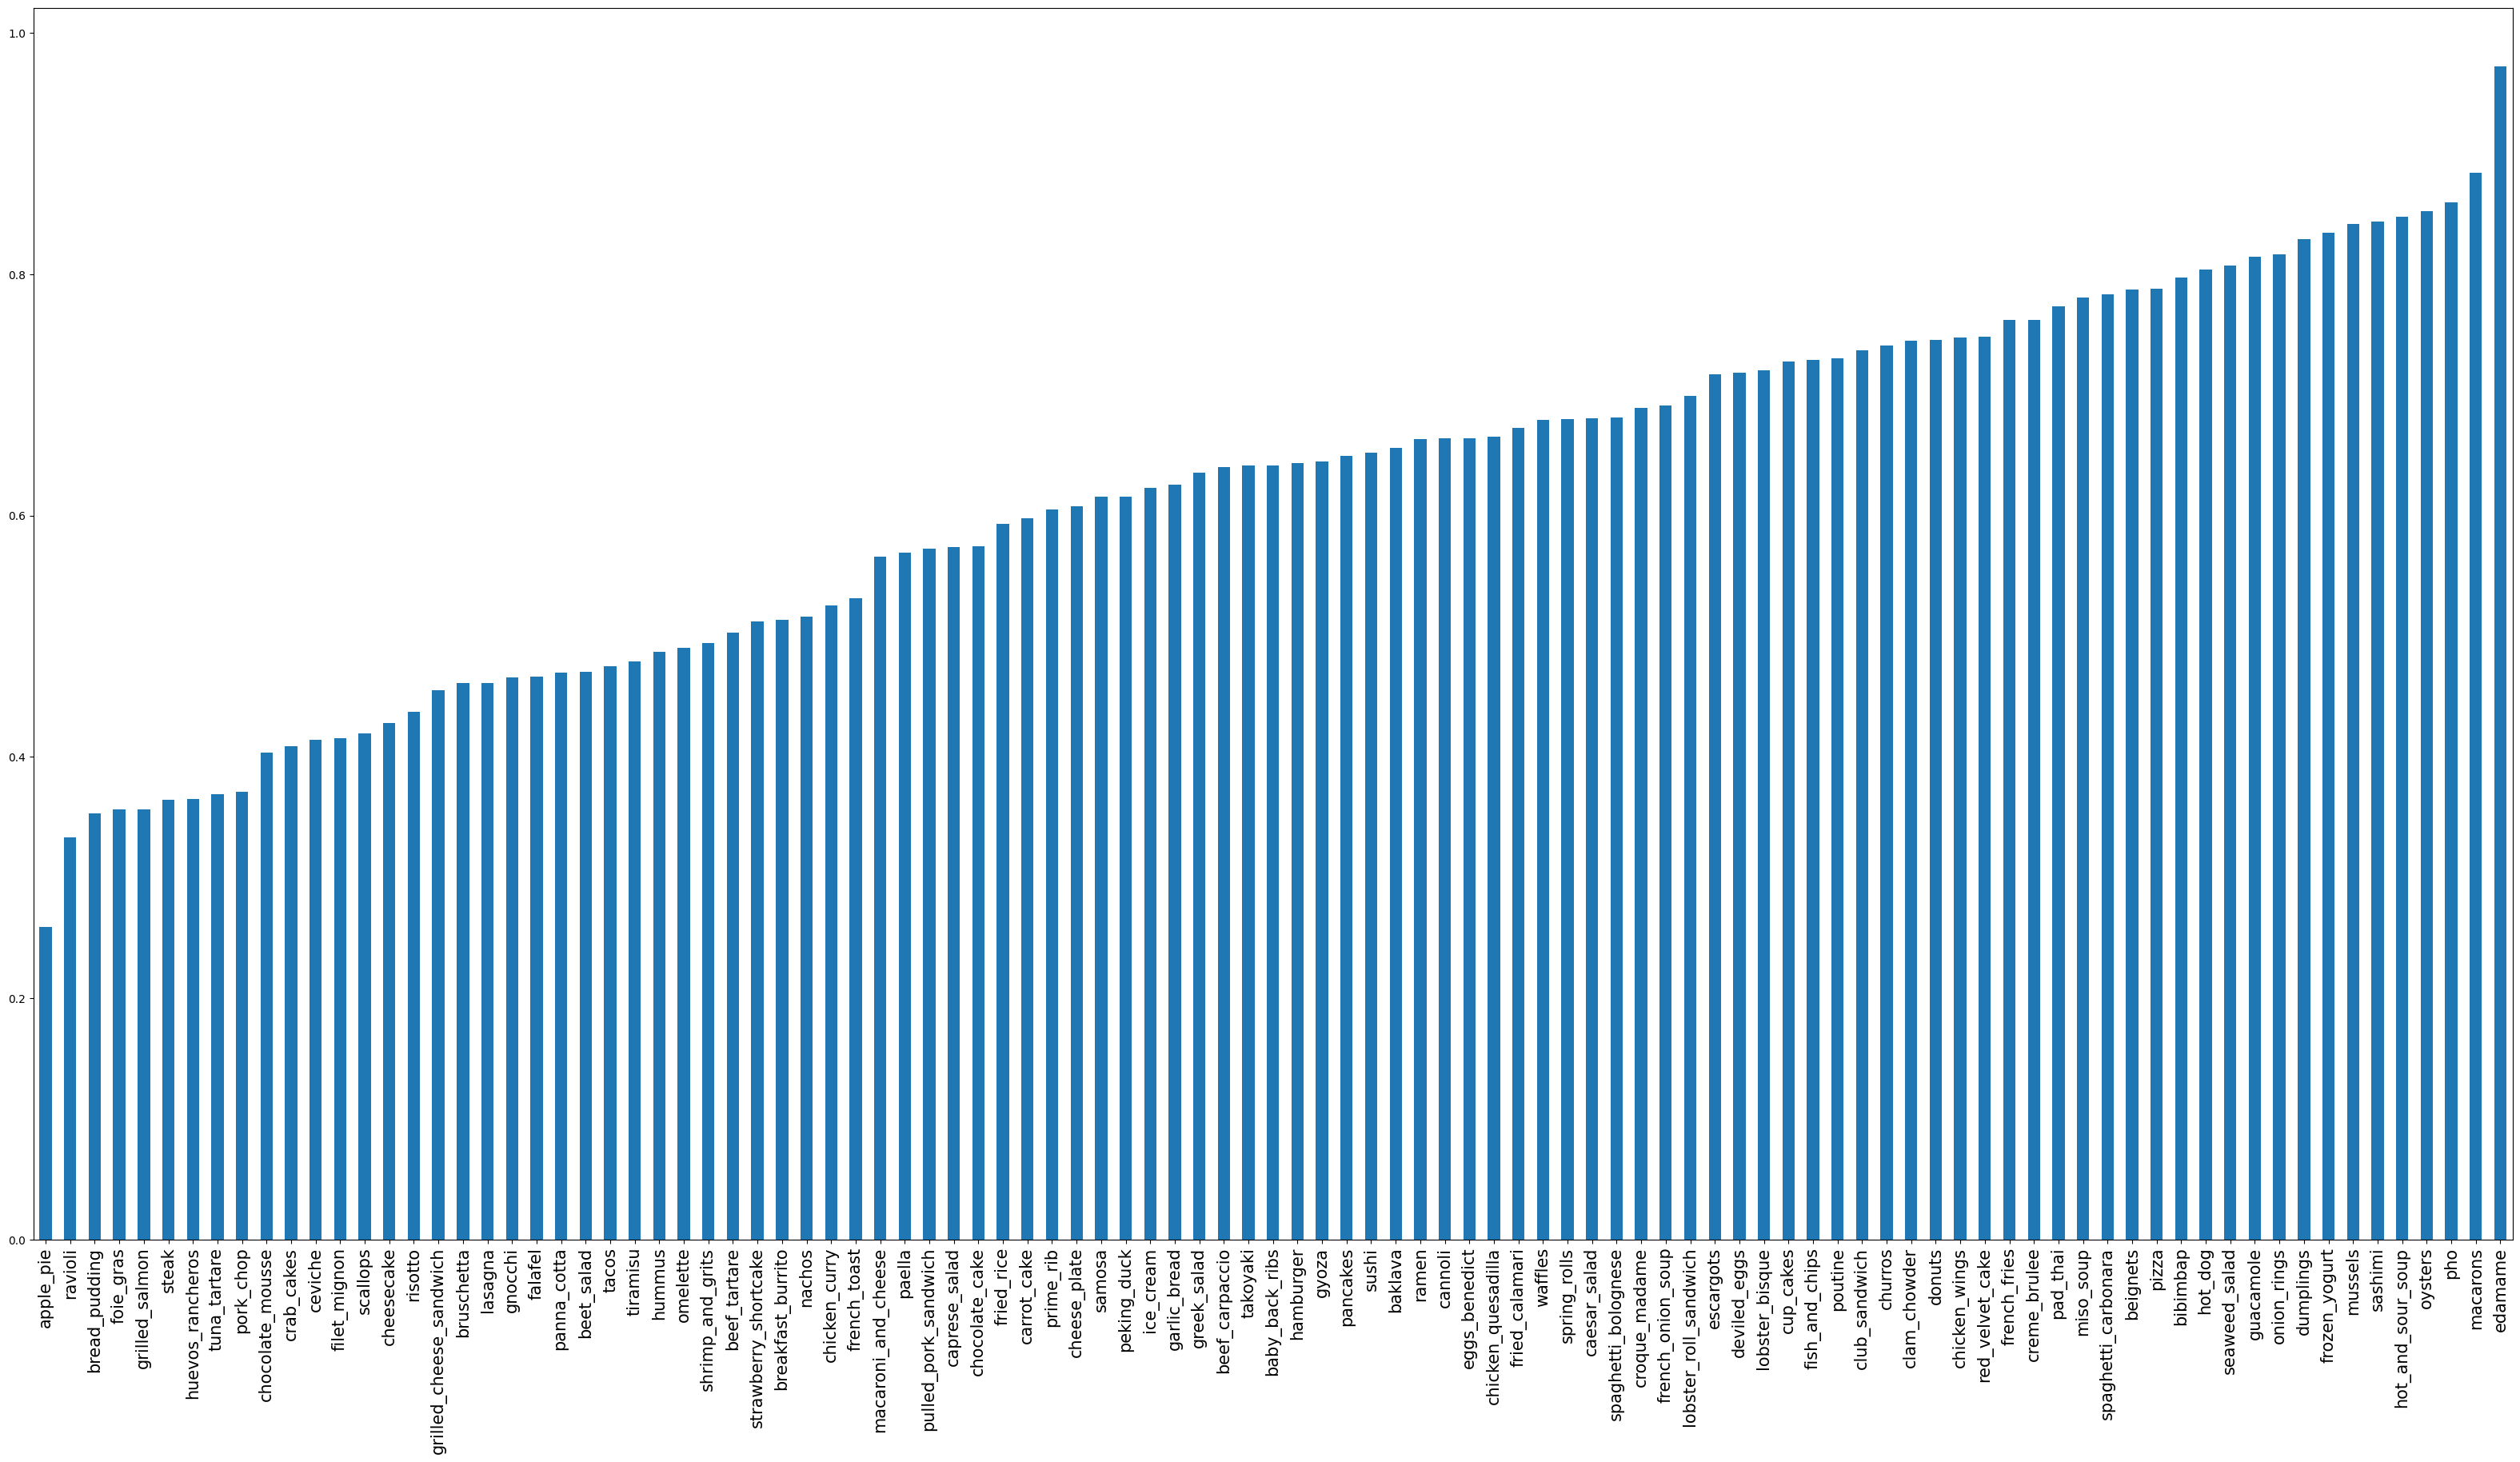

In [24]:
import pandas as pd

f1_scores = pd.Series(class_f1_scores).sort_values(ascending=True)
f1_scores.plot.bar(figsize=(40, 20))
plt.xticks(fontsize=15)

plt.show()